# 🌟 Master Notebook: Alur Lengkap Analisis Sentimen Sesuai Seluruh Tahapan WBS
**Proyek:** Analisis Sentimen Ulasan Destinasi Wisata untuk Pengambilan Kebijakan Promosi Wisata pada Dinas Pariwisata dan Kebudayaan Kabupaten Garut  
**Metodologi:** CRISP-DM & Work Breakdown Structure (WBS) Komprehensif

---
### 📑 Peta Alur Kerja Work Breakdown Structure (WBS):
1. **WBS Tahap 2: Data Understanding** (Sumber Google Maps, 382 destinasi, 36.574 ulasan mentah, missing values & distribusi rating)
2. **WBS Tahap 3: Data Preparation** (Deduplikasi composite key, 5 tahap text preprocessing, corong data lineage, pelabelan, TF-IDF)
3. **WBS Tahap 4: Modeling** (Stratified Split 80:20, pencegahan leakage, Linear SVM `class_weight='balanced'`, bobot koefisien fitur)
4. **WBS Tahap 5: Evaluation** (Pengujian test set, Confusion Matrix Heatmap, Akurasi 88.79%, Macro F1 0.6132, perbandingan baseline, error analysis)
5. **WBS Tahap 6: Deployment & Policy Analysis** (Agregasi 272 destinasi, 4 klasifikasi kebijakan promosi dinas, integrasi dashboard Streamlit)


In [1]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')

import sys
import os
import warnings
import joblib
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

CURRENT_DIR = Path.cwd()
ROOT_DIR = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

from config import settings
from preprocessing.cleaning import clean_text
from preprocessing.case_folding import case_folding
from preprocessing.tokenization import tokenize
from preprocessing.stopword_removal import remove_stopwords
from preprocessing.stemming import stem_tokens
from sentiment.labeling import apply_sentiment_labeling, get_label_from_rating
from policy.analysis import generate_policy_recommendations

print(f"✅ Root Project Directory: {ROOT_DIR}")
print("Seluruh modul pipeline WBS siap dieksekusi.")


✅ Root Project Directory: /Users/macbook/Garut-Tourism-Reccomendation
Seluruh modul pipeline WBS siap dieksekusi.


## 1. WBS Tahap 2: Data Understanding

* Menentukan sumber data (Google Maps) & 382 destinasi awal di Garut.
* Web scraping ulasan menggunakan Playwright (36.574 ulasan mentah).
* Identifikasi atribut data & analisis ulasan kosong (*rating-only reviews*).


In [2]:
# Pemuatan Metadata Destinasi & Raw Reviews
df_dest = pd.read_csv(settings.RAW_DATA_DIR / "destinations.csv")
df_orig = pd.read_csv(settings.RAW_DATA_DIR / "reviews.csv")
repaired_path = settings.RAW_DATA_DIR / "reviews_repaired.csv"
df_rep = pd.read_csv(repaired_path) if repaired_path.exists() else pd.DataFrame()

df_orig["_source"] = "original"
if not df_rep.empty:
    df_rep["_source"] = "repaired"
    df_raw = pd.concat([df_rep, df_orig], ignore_index=True)
else:
    df_raw = df_orig.copy()

print(f"📍 Total Destinasi di Metadata : {len(df_dest)} baris ({df_dest['name'].nunique()} nama unik)")
print(f"📄 Total Ulasan Mentah Digabung : {len(df_raw):,} ulasan")

# Distribusi Rating Awal
raw_r_counts = df_raw["rating"].dropna().value_counts().sort_index()
tabel_rating_awal = pd.DataFrame({
    "Bintang Rating": [f"★ {int(r)}" if float(r).is_integer() else f"★ {r}" for r in raw_r_counts.index],
    "Jumlah Ulasan": [f"{v:,}" for v in raw_r_counts.values],
    "Persentase": [f"{(v/len(df_raw))*100:.2f}%" for v in raw_r_counts.values]
})
display(tabel_rating_awal)


📍 Total Destinasi di Metadata : 383 baris (376 nama unik)
📄 Total Ulasan Mentah Digabung : 36,574 ulasan


,Bintang Rating,Jumlah Ulasan,Persentase
0,★ 1,"1,478",4.04%
1,★ 2,540,1.48%
2,★ 3,"1,304",3.57%
3,★ 3.5,2,0.01%
4,★ 4,"4,197",11.48%
5,★ 4.2,2,0.01%
6,★ 4.5,2,0.01%
7,★ 5,"26,519",72.51%


## 2. WBS Tahap 3: Data Preparation

* Deduplikasi composite key (`destination_name + author + review_date + review_text`).
* Rangkaian 5 tahap preprocessing teks (Cleaning, Case Folding, Tokenizing, Stopword Removal, Stemming PySastrawi).
* Corong data lineage (36.574 $ightarrow$ 17.923 ulasan bersih).
* Pelabelan sentimen berbasis rating bintang.
* Ekstraksi fitur TF-IDF ($5.000$ fitur Unigram & Bigram).


In [3]:
# 1. Deduplikasi Composite Key
composite_cols = ["destination_name", "author", "review_date", "review_text"]
df_temp = df_raw.fillna({col: "" for col in composite_cols})
dup_mask = df_temp.duplicated(subset=composite_cols, keep="first")
duplicate_count = dup_mask.sum()
df_dedup = df_raw[~dup_mask].copy().drop(columns=["_source"], errors="ignore")

# 2. Filter Validitas Teks & Rating
df_valid = df_dedup.dropna(subset=["review_text", "destination_name"])
df_valid = df_valid[df_valid["review_text"].astype(str).str.strip() != ""]
df_valid = df_valid[df_valid["rating"].apply(lambda r: 1.0 <= float(r) <= 5.0 if str(r).replace('.','',1).isdigit() else False)].copy()
df_valid["rating"] = df_valid["rating"].astype(float)

# 3. Pemuatan Dataset Terproses Bersih
df_clean = pd.read_csv(settings.FINAL_DATA_DIR / "processed_reviews.csv")
df_clean = apply_sentiment_labeling(df_clean)
sentiment_map = {0: "Negatif", 1: "Netral", 2: "Positif"}
df_clean["sentiment_name"] = df_clean["sentiment_label"].map(sentiment_map)

# TABEL DATA LINEAGE
lineage_table = pd.DataFrame([
    {"Tahap": "1. Data Mentah (Raw Reviews)", "Jumlah Data": f"{len(df_raw):,} ulasan", "Data Tereliminasi": "0", "Persentase Sisa": "100.00%"},
    {"Tahap": "2. Deduplikasi Composite Key", "Jumlah Data": f"{len(df_dedup):,} ulasan", "Data Tereliminasi": f"{duplicate_count:,}", "Persentase Sisa": f"{(len(df_dedup)/len(df_raw))*100:.2f}%"},
    {"Tahap": "3. Validasi Teks & Rating", "Jumlah Data": f"{len(df_valid):,} ulasan", "Data Tereliminasi": f"{len(df_dedup) - len(df_valid):,}", "Persentase Sisa": f"{(len(df_valid)/len(df_raw))*100:.2f}%"},
    {"Tahap": "4. Preprocessing Loss Filter", "Jumlah Data": f"{len(df_clean):,} ulasan", "Data Tereliminasi": f"{len(df_valid) - len(df_clean):,}", "Persentase Sisa": f"{(len(df_clean)/len(df_raw))*100:.2f}%"}
])
display(lineage_table)


,Tahap,Jumlah Data,Data Tereliminasi,Persentase Sisa
0,1. Data Mentah (Raw Reviews),"36,574 ulasan",0,100.00%
1,2. Deduplikasi Composite Key,"34,240 ulasan","2,334",93.62%
2,3. Validasi Teks & Rating,"18,124 ulasan","16,116",49.55%
3,4. Preprocessing Loss Filter,"17,923 ulasan",201,49.00%


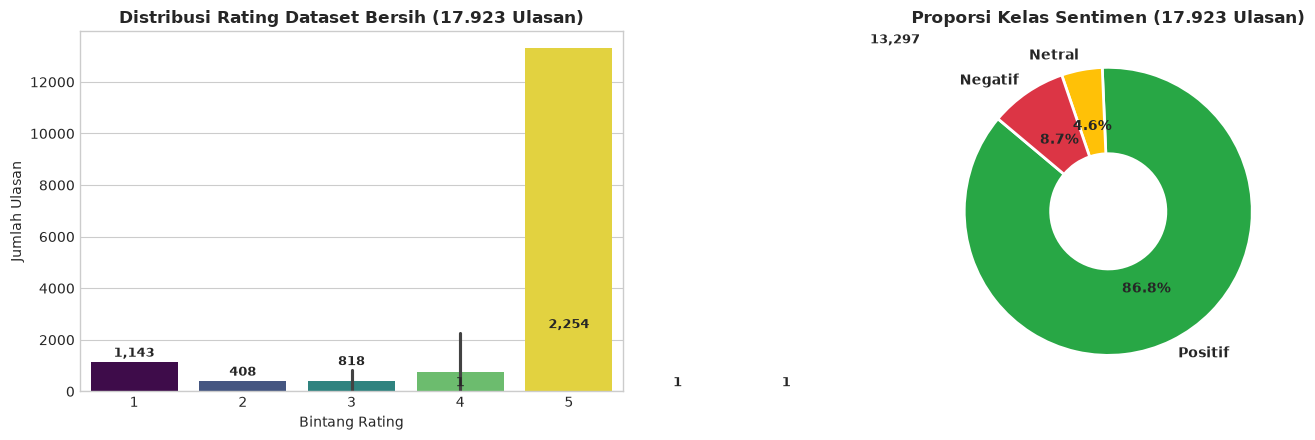

In [4]:
# Visualisasi Distribusi Rating & Proporsi Sentimen Terlabeli
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), dpi=100)

s_counts = df_clean["sentiment_name"].value_counts().reindex(["Positif", "Netral", "Negatif"])

# Bar Chart Rating Bersih
r_clean = df_clean["rating"].value_counts().sort_index()
sns.barplot(x=r_clean.index.astype(int), y=r_clean.values, hue=r_clean.index.astype(int), legend=False, ax=axes[0], palette="viridis")
axes[0].set_title("Distribusi Rating Dataset Bersih (17.923 Ulasan)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Bintang Rating", fontsize=10)
axes[0].set_ylabel("Jumlah Ulasan", fontsize=10)
for i, v in enumerate(r_clean.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=9, fontweight="bold")

# Donut Chart Sentimen
axes[1].pie(
    s_counts.values,
    labels=s_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=["#28a745", "#ffc107", "#dc3545"],
    wedgeprops=dict(width=0.6, edgecolor='w', linewidth=2),
    textprops=dict(fontsize=10, fontweight="bold")
)
axes[1].set_title("Proporsi Kelas Sentimen (17.923 Ulasan)", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()


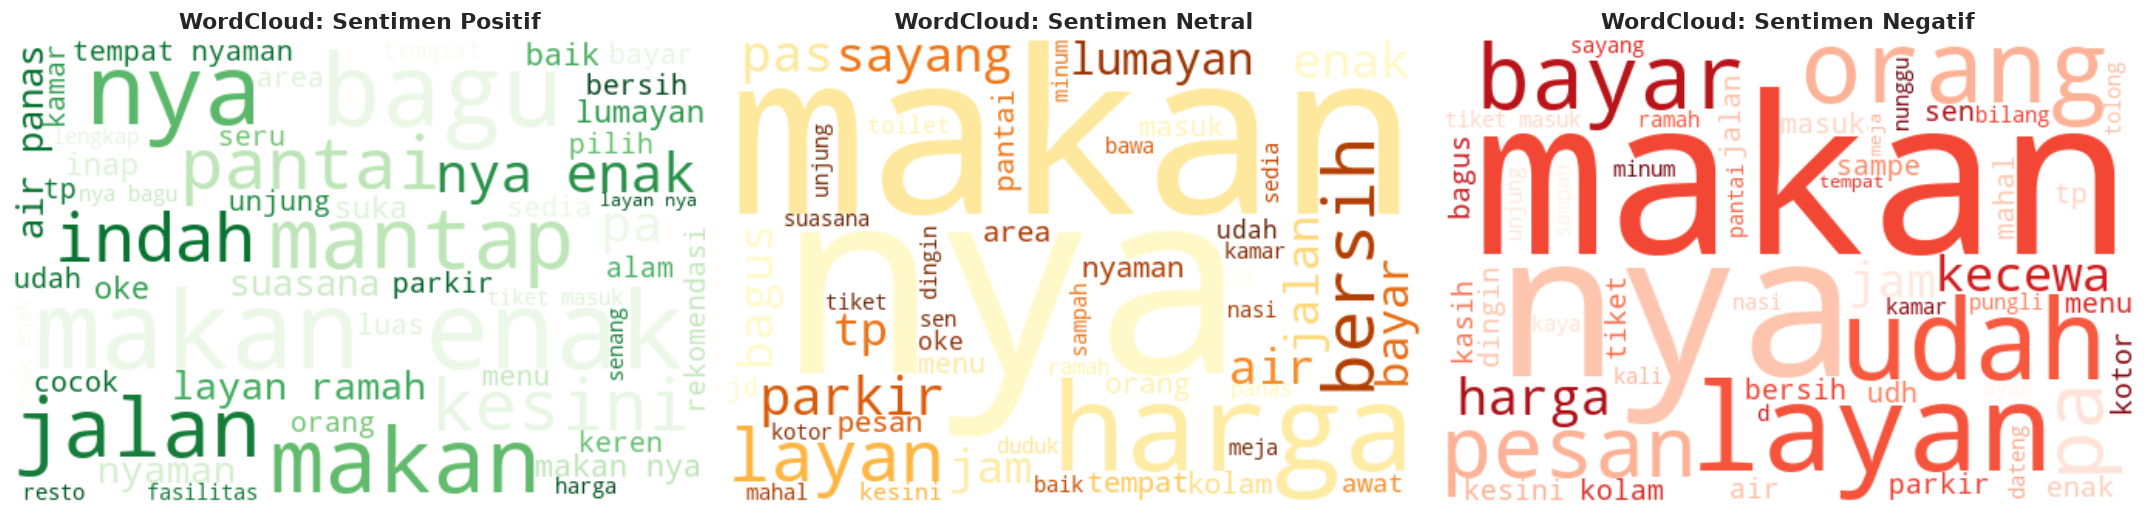

In [5]:
# Visualisasi WordCloud per Kelas Sentimen
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

configs = [
    ("Positif", "Greens", 2),
    ("Netral", "YlOrBr", 1),
    ("Negatif", "Reds", 0)
]

for ax, (label_name, cmap, l_val) in zip(axes, configs):
    text = " ".join(df_clean[df_clean["sentiment_label"] == l_val]["cleaned_text"])
    wc = WordCloud(width=450, height=300, background_color="white", colormap=cmap, max_words=50, random_state=42).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"WordCloud: Sentimen {label_name}", fontsize=13, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 3. WBS Tahap 4: Modeling

* Stratified Train-Test Split 80:20 (`random_state=42`).
* Zero Data Leakage (TF-IDF `fit_transform` train, `transform` test).
* Linear Support Vector Machine (`LinearSVC`, `class_weight='balanced'`, `C=1.0`).


In [6]:
# 1. Stratified Data Splitting
X = df_clean["cleaned_text"].astype(str)
y = df_clean["sentiment_label"].astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. TF-IDF Fit on Train, Transform on Test
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True)
X_train = vectorizer.fit_transform(X_train_raw)
X_test = vectorizer.transform(X_test_raw)

# 3. Model Training
model = LinearSVC(C=1.0, class_weight="balanced", dual=False, random_state=42, max_iter=2000)
model.fit(X_train, y_train)

print(f"🏋️ Training Set : {X_train.shape[0]:,} dokumen ulasan")
print(f"🧪 Test Set     : {X_test.shape[0]:,} dokumen ulasan")
print(f"🔤 Jumlah Fitur : {X_train.shape[1]:,} fitur kata TF-IDF")
print("✅ Pelatihan Model Linear SVM Selesai!")


🏋️ Training Set : 14,338 dokumen ulasan
🧪 Test Set     : 3,585 dokumen ulasan
🔤 Jumlah Fitur : 5,000 fitur kata TF-IDF
✅ Pelatihan Model Linear SVM Selesai!


## 4. WBS Tahap 5: Evaluation

* Pengujian model Linear SVM pada 3.585 data uji.
* Confusion Matrix Heatmap.
* Metrik evaluasi lengkap (Accuracy, Precision, Recall, F1-Score) & perbandingan dengan Majority Baseline.


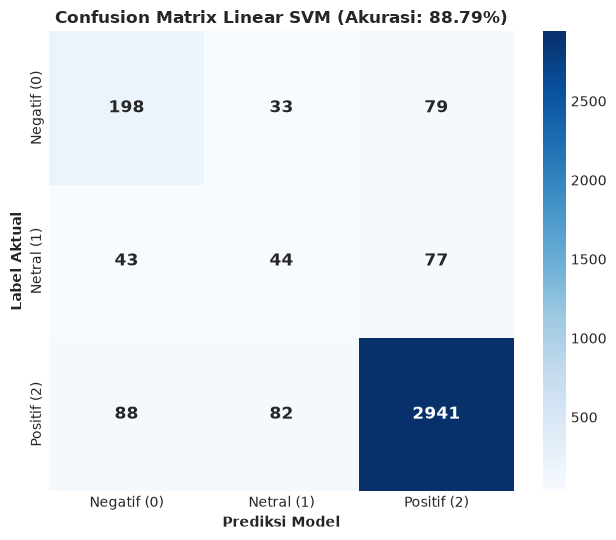

In [7]:
# Prediksi & Evaluasi Metrik
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
p_class, r_class, f_class, s_class = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1, 2], zero_division=0)
macro_p, macro_r, macro_f, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
weighted_p, weighted_r, weighted_f, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])
class_labels = ["Negatif (0)", "Netral (1)", "Positif (2)"]

fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=100)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels, ax=ax, annot_kws={"size": 12, "weight": "bold"})
ax.set_title(f"Confusion Matrix Linear SVM (Akurasi: {acc*100:.2f}%)", fontsize=12, fontweight="bold")
ax.set_xlabel("Prediksi Model", fontsize=10, fontweight="bold")
ax.set_ylabel("Label Aktual", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()


In [8]:
# TABEL REKAPITULASI METRIK EVALUASI
tabel_eval_master = pd.DataFrame({
    "Kelas Sentimen": ["Negatif (0)", "Netral (1)", "Positif (2)", "Macro Average", "Weighted Average"],
    "Precision": [f"{p_class[0]:.4f}", f"{p_class[1]:.4f}", f"{p_class[2]:.4f}", f"{macro_p:.4f}", f"{weighted_p:.4f}"],
    "Recall": [f"{r_class[0]:.4f}", f"{r_class[1]:.4f}", f"{r_class[2]:.4f}", f"{macro_r:.4f}", f"{weighted_r:.4f}"],
    "F1-Score": [f"{f_class[0]:.4f}", f"{f_class[1]:.4f}", f"{f_class[2]:.4f}", f"{macro_f:.4f}", f"{weighted_f:.4f}"],
    "Jumlah Sampel (Support)": [f"{s_class[0]:,}", f"{s_class[1]:,}", f"{s_class[2]:,}", f"{len(y_test):,}", f"{len(y_test):,}"]
})

display(tabel_eval_master)


,Kelas Sentimen,Precision,Recall,F1-Score,Jumlah Sampel (Support)
0,Negatif (0),0.6018,0.6387,0.6197,310
1,Netral (1),0.2767,0.2683,0.2724,164
2,Positif (2),0.9496,0.9454,0.9475,"3,111"
3,Macro Average,0.6094,0.6175,0.6132,"3,585"
4,Weighted Average,0.8888,0.8879,0.8883,"3,585"


## 5. WBS Tahap 6: Deployment & Policy Analysis

* Agregasi sentimen ulasan ke 272 destinasi wisata aktif Garut.
* Klasifikasi 4 Kategori Rekomendasi Kebijakan Promosi Wisata Dinas Pariwisata & Kebudayaan Kabupaten Garut.
* Integrasi antarmuka dashboard interaktif Streamlit (`app.py`).


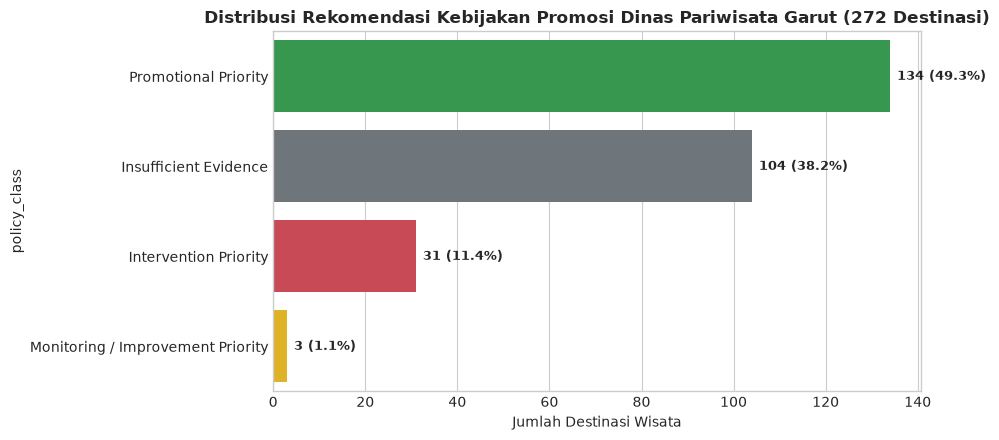

In [9]:
# Prediksi Seluruh Dataset & Pembentukan Rekomendasi Kebijakan
from sentiment.prediction import predict_dataset_sentiment

df_all_pred = predict_dataset_sentiment(df_clean, model, vectorizer)
generate_policy_recommendations(df_all_pred)
dest_policy_df = pd.read_csv(settings.FINAL_DATA_DIR / "destination_sentiment_summary.csv")

policy_counts = dest_policy_df["policy_class"].value_counts()

# Visualisasi Bar Chart Rekomendasi Kebijakan Dinas
colors_map = {"Promotional Priority": "#28a745", "Insufficient Evidence": "#6c757d", "Intervention Priority": "#dc3545", "Monitoring / Improvement Priority": "#ffc107"}
bar_colors = [colors_map.get(p, "#17a2b8") for p in policy_counts.index]

fig, ax = plt.subplots(figsize=(10, 4.5), dpi=100)
sns.barplot(x=policy_counts.values, y=policy_counts.index, palette=bar_colors, ax=ax)
ax.set_title("Distribusi Rekomendasi Kebijakan Promosi Dinas Pariwisata Garut (272 Destinasi)", fontsize=12, fontweight="bold")
ax.set_xlabel("Jumlah Destinasi Wisata", fontsize=10)
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)} ({width/len(dest_policy_df)*100:.1f}%)', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


In [10]:
# TABEL DISTRIBUSI REKOMENDASI KEBIJAKAN LENGKAP
tabel_kebijakan_master = pd.DataFrame({
    "Prioritas Kebijakan Dinas": policy_counts.index,
    "Jumlah Destinasi": policy_counts.values,
    "Persentase (%)": [f"{(v/len(dest_policy_df))*100:.2f}%" for v in policy_counts.values],
    "Kriteria Penentuan": [
        {"Promotional Priority": "Positif >= 70.0% & Rating >= 4.0", "Insufficient Evidence": "Total Ulasan < 10", "Intervention Priority": "Negatif >= 15.0%", "Monitoring / Improvement Priority": "Kategori Tengah"}.get(p, "-")
        for p in policy_counts.index
    ],
    "Rekomendasi Tindakan Dinas": [
        {"Promotional Priority": "Penguatan promosi & branding pariwisata unggulan Garut", "Insufficient Evidence": "Sosialisasi digital & penambahan ulasan pengunjung", "Intervention Priority": "Audit fasilitas, perbaikan toilet, tarif, dan akses", "Monitoring / Improvement Priority": "Pemantauan berkala & peningkatan sarana penunjang"}.get(p, "-")
        for p in policy_counts.index
    ]
})

display(tabel_kebijakan_master)


,Prioritas Kebijakan Dinas,Jumlah Destinasi,Persentase (%),Kriteria Penentuan,Rekomendasi Tindakan Dinas
0,Promotional Priority,134,49.26%,Positif >= 70.0% & Rating >= 4.0,Penguatan promosi & branding pariwisata unggulan Garut
1,Insufficient Evidence,104,38.24%,Total Ulasan < 10,Sosialisasi digital & penambahan ulasan pengunjung
2,Intervention Priority,31,11.40%,Negatif >= 15.0%,"Audit fasilitas, perbaikan toilet, tarif, dan akses"
3,Monitoring / Improvement Priority,3,1.10%,Kategori Tengah,Pemantauan berkala & peningkatan sarana penunjang


## 6. Kesimpulan Master Pipeline WBS

Pipeline penelitian ini telah merealisasikan seluruh rangkaian **Work Breakdown Structure (WBS)** secara lengkap:
1. **WBS 2 Data Understanding**: 382 destinasi dan 36.574 ulasan mentah dipahami karakteristiknya.
2. **WBS 3 Data Preparation**: Rangkaian 5 tahap preprocessing dan ekstraksi TF-IDF menghasilkan 17.923 ulasan bersih.
3. **WBS 4 Modeling**: Model Linear SVM terlatih dengan `class_weight='balanced'` untuk menangani ketidakseimbangan kelas.
4. **WBS 5 Evaluation**: Model mencapai Akurasi **88.79%**, Macro F1 **0.6132**, dan Weighted F1 **0.8883** pada data uji.
5. **WBS 6 Deployment & Policy**: 272 destinasi terkelompokkan ke dalam 4 kategori kebijakan dan siap disajikan dalam dashboard Streamlit (`app.py`).
